# Chapter 12 — Motion
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 12 — Motion.

A suspension bridge can sway two feet and remain perfectly healthy, while a girder that deflects a fraction of a millimeter but yields has failed — the difference is not motion, but *strain*.

Mechanics begins with motion: the description of how bodies move, deform, and resist. Before we can speak of stress or strain, we need a language for displacement and its spatial derivatives. That language is *kinematics*, and it connects what we can see (deflection) to what we can measure (surface strain) and what we ultimately care about (internal stress).

The demonstration here uses the simply-supported beam as a canonical example — not because beams are the most interesting structure, but because their behavior is exact and analytically transparent. Every quantity plotted can be derived from first principles: the deflection from integration of the moment–curvature relation, the bending strain from the flexure formula. This makes the notebook a verification tool as well as an illustration: if your strain gage reads something very different from what this code predicts, the discrepancy is worth investigating.

**This notebook demonstrates:**
1. Deflection and outer-fiber bending strain along a simply-supported beam under a mid-span point load

In [1]:
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Save figures where the book's \includegraphics expects to find them.
OUT_DIR = Path("../src/media/ch12")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Beam Deflection and Bending Strain

For a simply-supported beam under a mid-span point load, the deflection and bending moment distributions are both piecewise and symmetric. The moment is triangular — rising linearly from zero at each support to P·L/4 at mid-span — and the curvature follows the moment exactly through the flexure relation M = EIκ. Surface strain is proportional to curvature and to the distance from the neutral axis: ε = M·c / (EI), where c is the distance to the outer fiber.

Two observations matter for instrumentation planning. First, the maximum strain occurs at mid-span on the outer fiber — that is where a gage for peak-stress monitoring belongs. Second, the strain is zero at the neutral axis regardless of position along the beam — a gage at the centroid reads nothing useful. The figure shows both distributions together so the relationship between deflection shape and strain distribution is visible simultaneously.

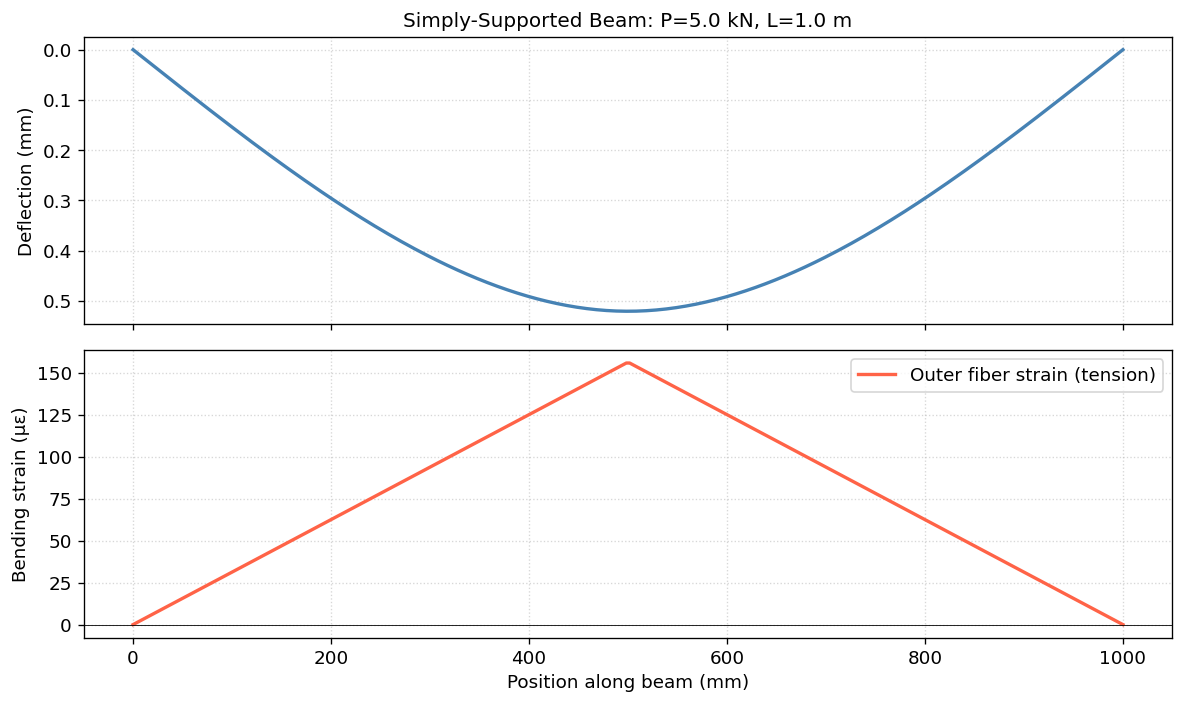

Max deflection at mid-span: 0.521 mm
Max bending strain at outer fiber: 155.7 με


In [2]:
# Displacement field -> strain: eps_xx = du/dx, eps_yy = dv/dy, gamma_xy = du/dy + dv/dx.
# Here we work a canonical case whose displacement field is known in closed form:
# a simply-supported beam under a mid-span point load.

# --- Beam properties (steel, symmetric section) ---
L = 1.0       # m    span between supports
E = 200e9     # Pa   Young's modulus (steel)
I = 1e-6      # m^4  second moment of area of the cross-section
P = 5000.0    # N    downward point load applied at mid-span
c = 0.025     # m    distance from neutral axis to the outer fiber
N_POINTS = 300  # number of stations sampled along the span


def beam_deflection(x, L, E, I, P):
    """Downward deflection (m) of a simply-supported beam under a mid-span
    point load P, evaluated at positions x (m).

    The closed form is valid on the left half; we mirror it to the right
    half by using the distance to the nearer support, so no explicit
    mid-span split (and no fragile array index) is required. Positive
    values are downward.
    """
    xi = np.minimum(x, L - x)                      # distance to the nearer support
    return P * xi / (48 * E * I) * (3 * L**2 - 4 * xi**2)


def bending_moment(x, L, P):
    """Bending moment M(x) (N.m) for a simply-supported beam under a mid-span
    point load. Triangular: zero at the supports, P*L/4 at mid-span."""
    xi = np.minimum(x, L - x)                      # distance to the nearer support
    return (P / 2) * xi


x = np.linspace(0, L, N_POINTS)
y = beam_deflection(x, L, E, I, P)
M = bending_moment(x, L, P)

# Outer-fiber bending strain from the flexure formula eps = M*c/(E*I).
# Positive here = tension on the bottom (outer) fiber of a sagging beam.
eps_outer = M * c / (E * I)  # dimensionless (strain)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(x*1000, y*1000, 'steelblue', lw=2)
axes[0].set_ylabel('Deflection (mm)'); axes[0].invert_yaxis()
axes[0].set_title(f'Simply-Supported Beam: P={P/1000:.1f} kN, L={L} m')
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(x*1000, eps_outer*1e6, 'tomato', lw=2, label='Outer fiber strain (tension)')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_xlabel('Position along beam (mm)')
axes[1].set_ylabel('Bending strain (με)')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)
plt.tight_layout(); plt.savefig(OUT_DIR / 'fig12_nb1_beam_deflection_strain.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Max deflection at mid-span: {y.max()*1000:.3f} mm")
print(f"Max bending strain at outer fiber: {eps_outer.max()*1e6:.1f} με")

## Where to take this next

The beam above is deliberately the simplest exact case. A few concrete directions to extend it:

1. **Change the load case.** Swap the mid-span point load for a uniformly distributed load, an off-center point load, or a fixed-free cantilever (the geometry behind the chapter's bending worked example). Re-derive `beam_deflection` and `bending_moment`, then watch where the peak strain migrates — that is where a peak-stress gage belongs.
2. **Confirm the thickness scaling.** For a rectangular section, `I = b·h³/12` and `c = h/2`, so surface bending strain scales as `1/h²`. Sweep the thickness `h` over a realistic range, overlay the strain curves, and check that halving the thickness quadruples the surface strain — exactly the factor-of-four the chapter argues.
3. **Simulate a gage reading.** Sample `eps_outer` at a chosen gage location, add a few microstrain of Gaussian noise (seed the generator first with `np.random.default_rng(0)`), then invert the flexure relation to recover the applied load. It is a miniature preview of the load-recovery problem the transducer chapters build on.